## Environment setup

In [6]:
from datetime import datetime 
import importlib
from functools import partial

import tensorflow as tf
from tensorflow.data import Dataset, TFRecordDataset
import tensorflow_datasets as tfds

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

# Notebooks run from VSCode use home directory as a base path
# while notebooks ran from JupyterLab use the current directory as a base path
import sys
sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")

# Change directory to the working directory
import os
os.chdir('/scratch_hdd/akalinow/ELITPC/PythonAnalysis/')

#Increase plots font size
params = {'legend.fontsize': 'xx-large',
          'figure.figsize': (10, 7),
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

### Load the dataset and convert to pandas DataFrame

In [ ]:
import io_functions as io
importlib.reload(io)

fileName = 'SimEvent_Track3D_TwoProng_gun_MC_2025-12-02T10-53.root'
fileName = 'SimEvent_Track3D_TwoProng_gun_MC_2025-12-02T11-08_Human.root'
dataPath = '/home/akalinow/scratch/ELITPC/TPCReco/build_with_TF/resources/'
rootFiles = [dataPath+fileName+':TPCData']

# Convert ROOT files to TF format and save to output directory
simOutputDir = 'SimEvent_Track3D_TwoProng_gun_MC_test'
io.convertROOT(rootFiles, simOutputDir, fields= io.simEventFields)

# uproot always takes the first branch with given name, unless 
# explicit branch is given as input path. Filtering by branches in
# iterate does not work. We have to give full path to the branch: TPCData/RecoEvent
rootFiles = [aFile+'/RecoEvent' for aFile in rootFiles]

# Convert ROOT files to TF format and save to output directory
recoOutputDir = 'RecoEvent_Track3D_TwoProng_gun_MC_test'
io.convertROOT(rootFiles, recoOutputDir, fields=io.recoEventFields)

# merge SimEvent and RecoEvent data

simOutputDir = 'SimEvent_Track3D_TwoProng_gun_MC_test'
recoOutputDir = 'RecoEvent_Track3D_TwoProng_gun_MC_test'

simDataset = tf.data.Dataset.load(simOutputDir, compression="GZIP")
recoDataset = tf.data.Dataset.load(recoOutputDir, compression="GZIP")

mergedDataset = tf.data.Dataset.zip((simDataset, recoDataset))
mergedDataset = mergedDataset.map(
    lambda sim, reco: {
        'sim': sim,
        'reco': reco
    }
)

# filter merged dataset
# calculate sim alpha length and select events with length > 30 mm
minAlphaLength = 30.0
mergedDataset = mergedDataset.filter(
    lambda x: tf.reduce_all(
        tf.greater(
            tf.sqrt(
                tf.math.reduce_sum(tf.square(x['sim'][1][:,0] - x['sim'][1][:,1]), axis=-1)
            ), minAlphaLength
        )
    )
)

# calculate sim alpha length and select events with length < 100 mm
maxAlphaLength = 10000.0
mergedDataset = mergedDataset.filter(
    lambda x: tf.reduce_all(
        tf.less(
            tf.sqrt(
                tf.math.reduce_sum(tf.square(x['sim'][1][:,0] - x['sim'][1][:,1]), axis=-1)
            ), maxAlphaLength
        )
    )
)

# save merged dataset
outputDir = 'MergedEvent_Track3D_TwoProng_gun_MC_test'
mergedDataset.save(outputDir, compression="GZIP")

In [8]:
%%time 

import utility_functions as utils
importlib.reload(utils)

dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC_test', compression="GZIP")

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1))).unbatch().as_numpy_iterator()
df = pd.DataFrame(data, columns=utils.columnsXYZ)

data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsXYZ)

df = df.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

Cause: could not parse the source code of <function <lambda> at 0x7061fc3b79c0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x7061fc3b79c0>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x70626c7ce480>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x70626c7ce480>: no matching AST found among candidates:

To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


2025-12-02 11:06:18.644781: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


CPU times: user 5.03 s, sys: 80.2 ms, total: 5.11 s
Wall time: 4.65 s


2025-12-02 11:06:21.007071: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Load the model


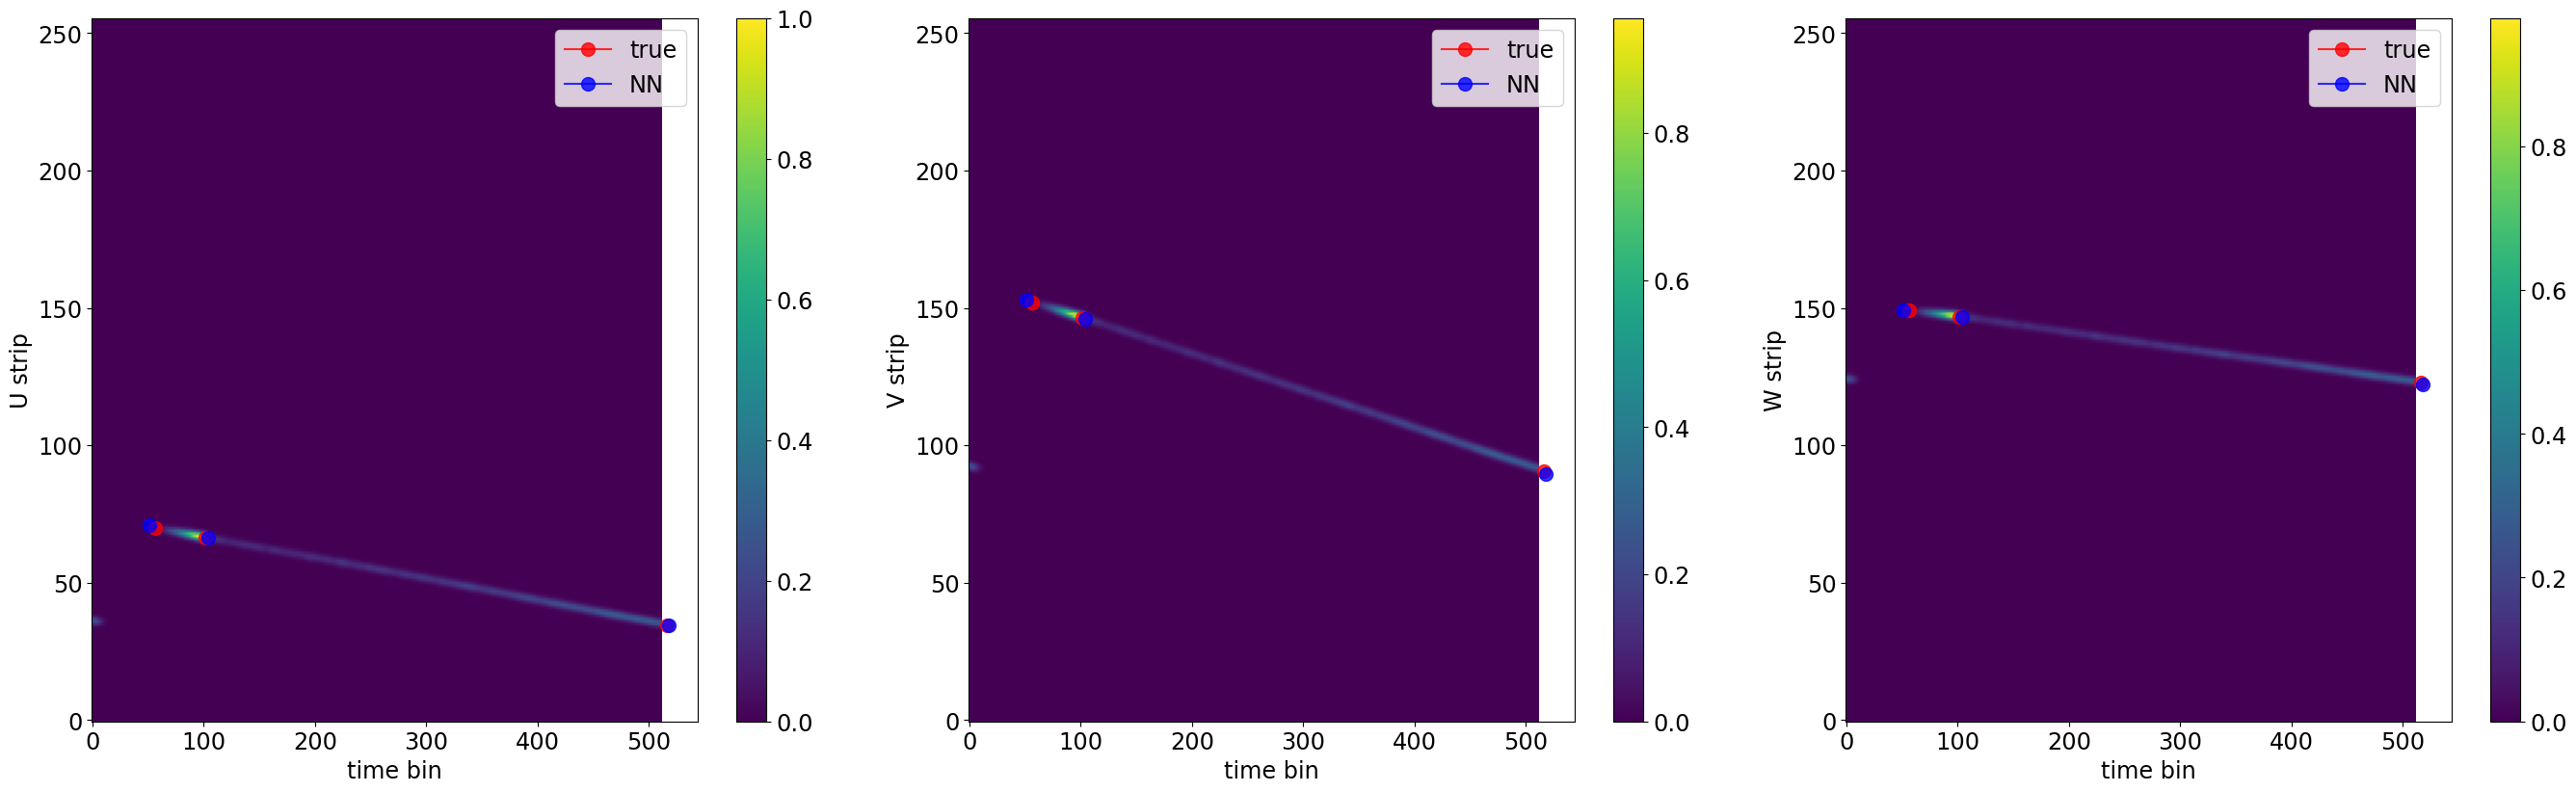

In [9]:
import plotting_functions as plf
importlib.reload(plf)

path = '/home/akalinow/scratch/ELITPC/PythonAnalysis/training/0200_2025_Dec_02_10_08_19.keras'
model = tf.keras.models.load_model(path)

#dataset_f = dataset.map(lambda x: (tf.where(x['sim'][0]>0.1, x['sim'][0], 0), x['sim'][1]))

x = iter(dataset.batch(1))
for i in range(1):
    item = next(x)
    plf.plotEvent(item['sim'], model=model)

### Resolution plots in XYZ

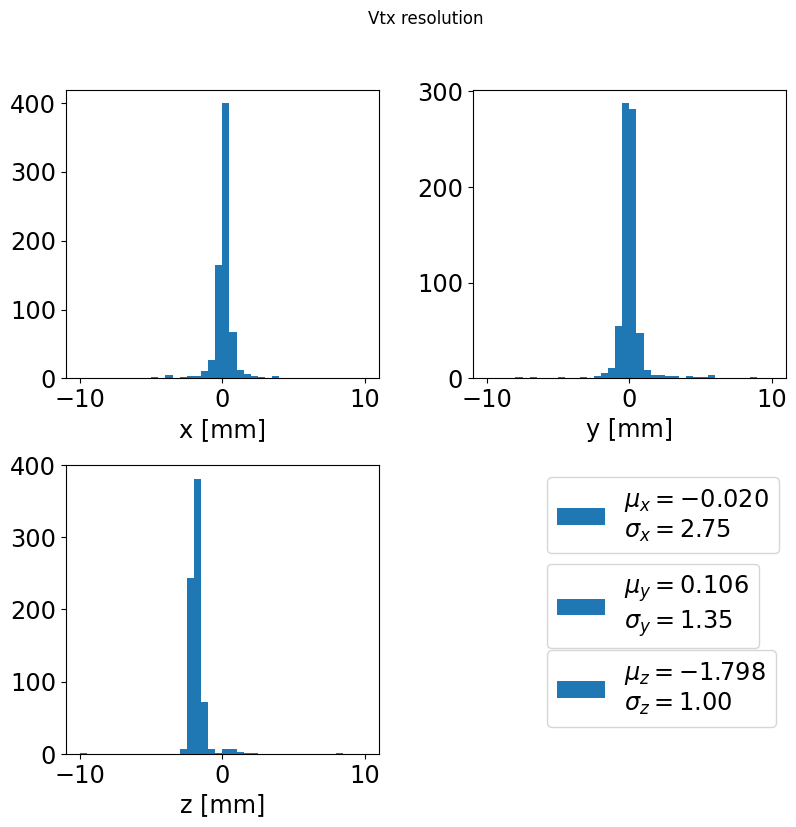

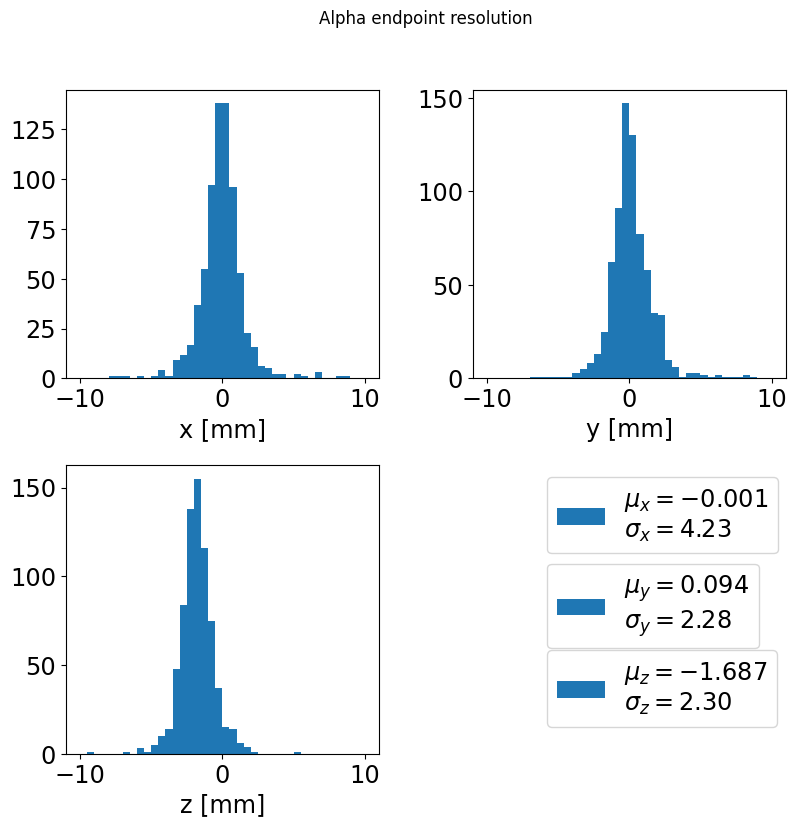

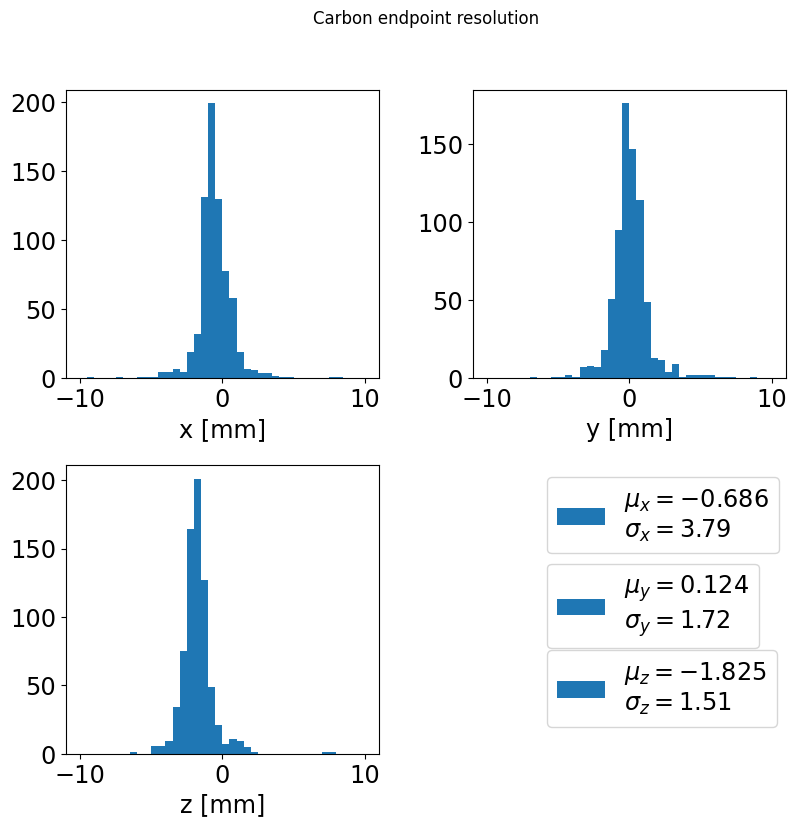

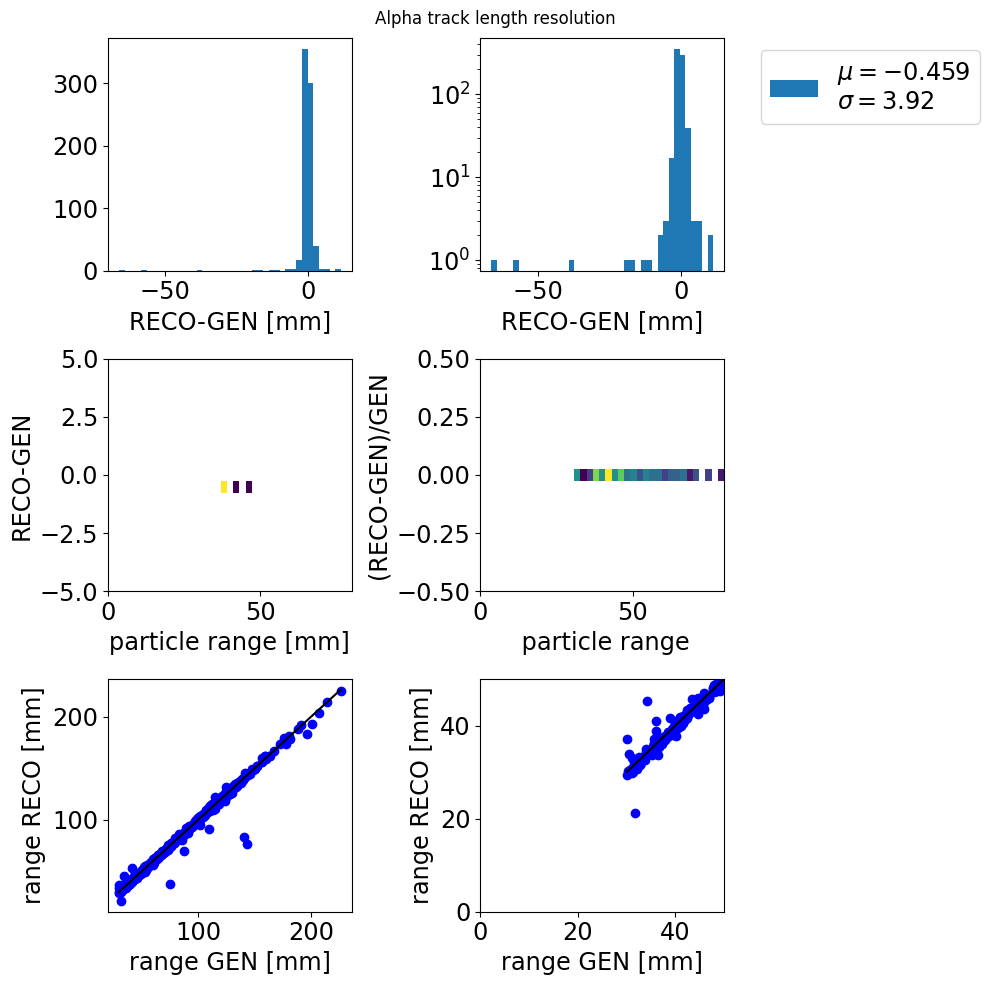

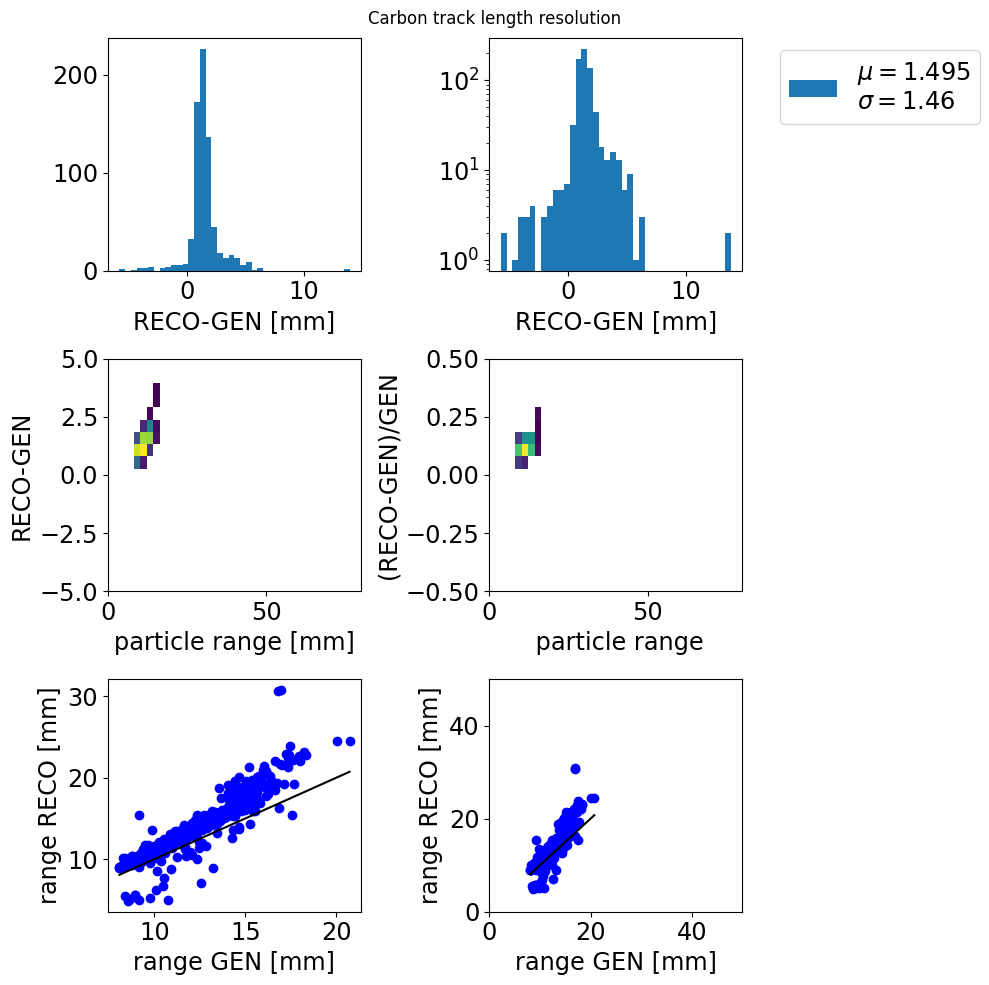

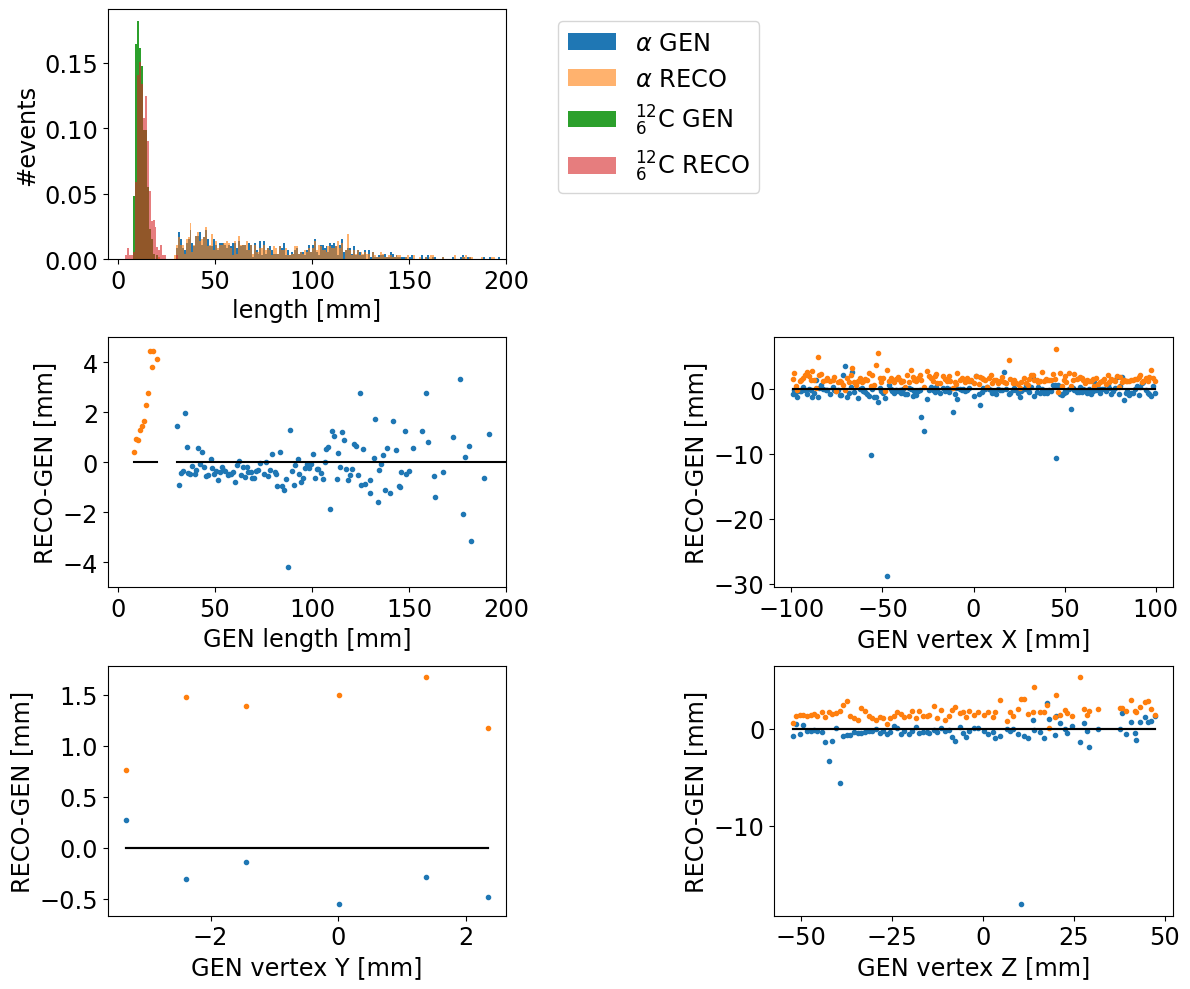

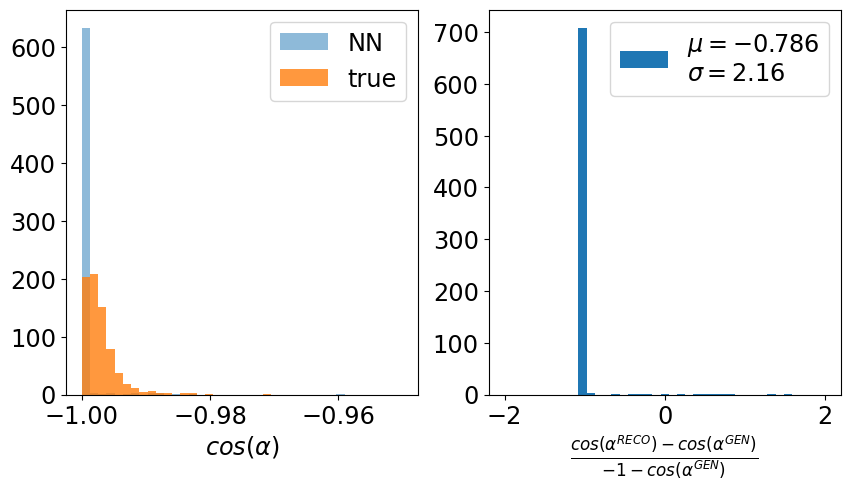

In [10]:
import plotting_functions as plf
importlib.reload(plf)

#plf.controlPlots(df)
plf.plotEndPointRes(df=df, edge="Vtx", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df, edge="Alpha", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df, edge="Carbon", coordinates=["x", "y", "z"])

plf.plotLengthPull(df, partName="Alpha")
plf.plotLengthPull(df, partName="Carbon")
plf.plotLengthPullEvolution(df)
plf.plotOpeningAngleCos(df)

### Resolution plots for filtered dataset

/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:199: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["d"+partName+"_sim"] = d_sim
/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:200: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["d"+partName+"_reco"] = d_reco
/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/plotting_functions.py:201: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

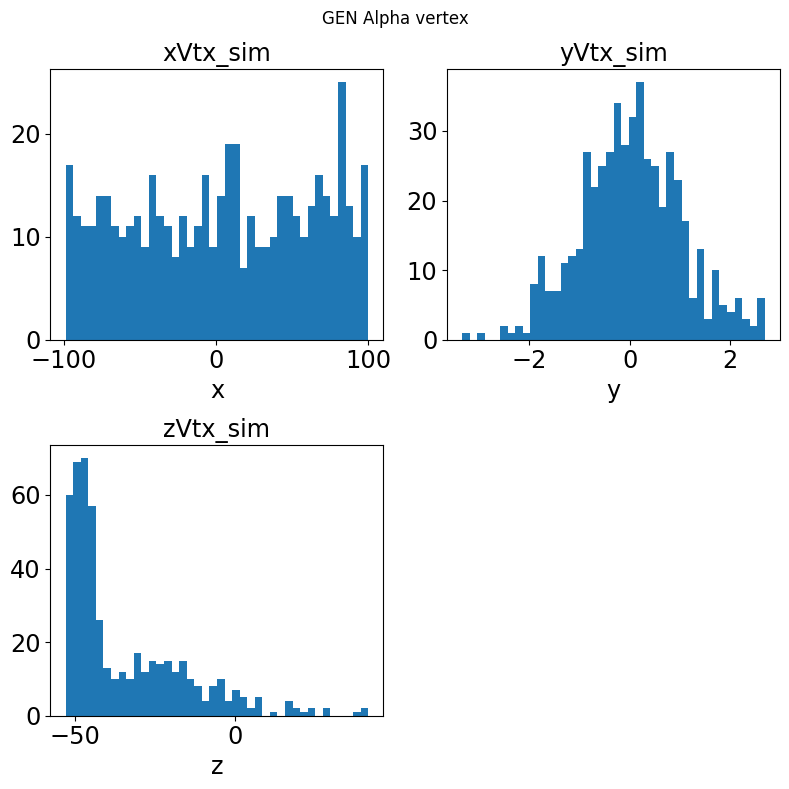

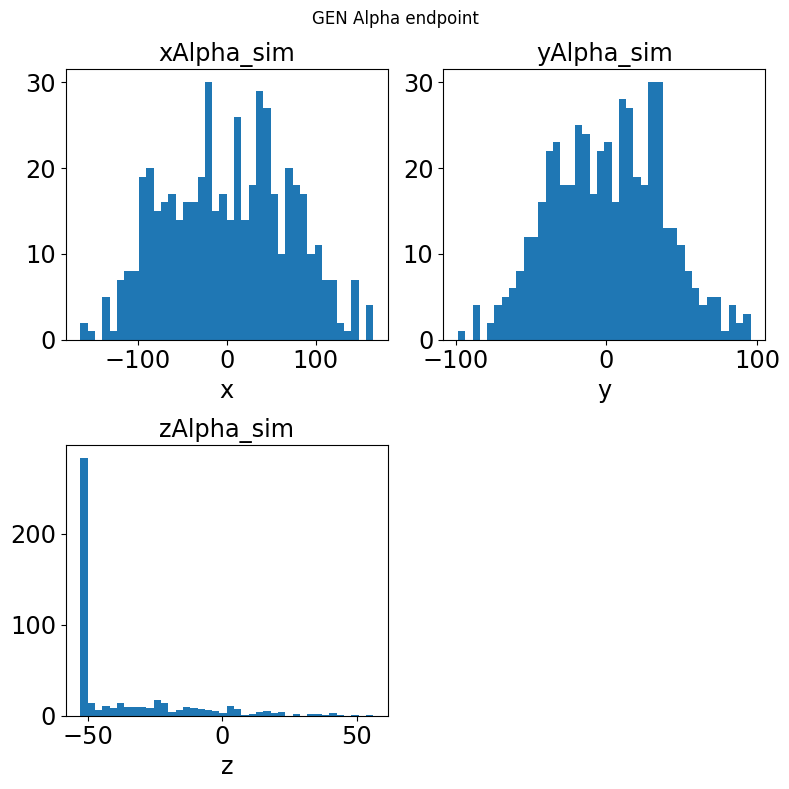

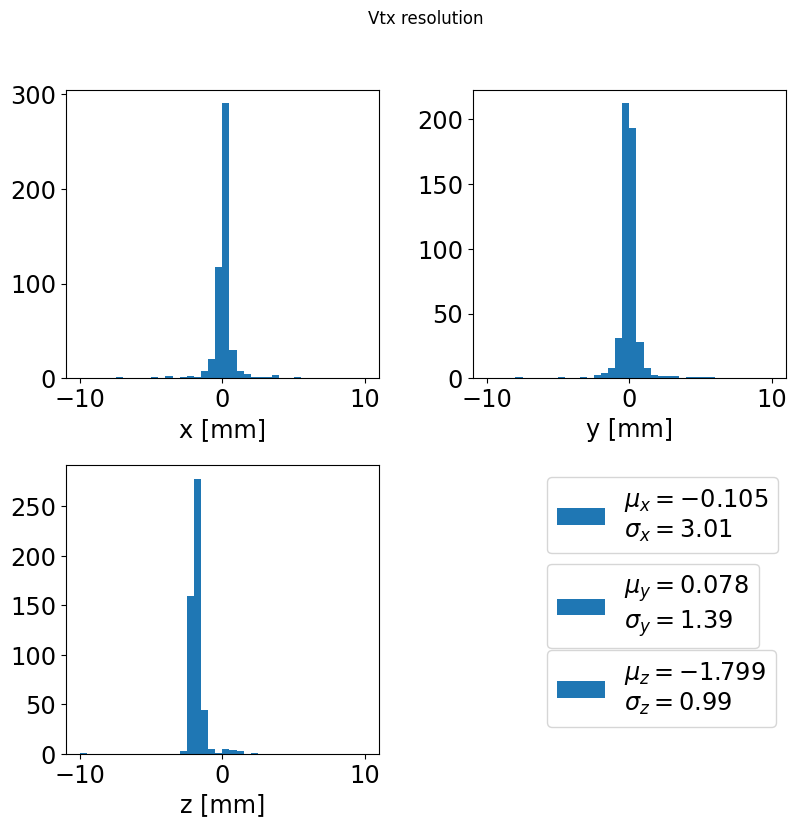

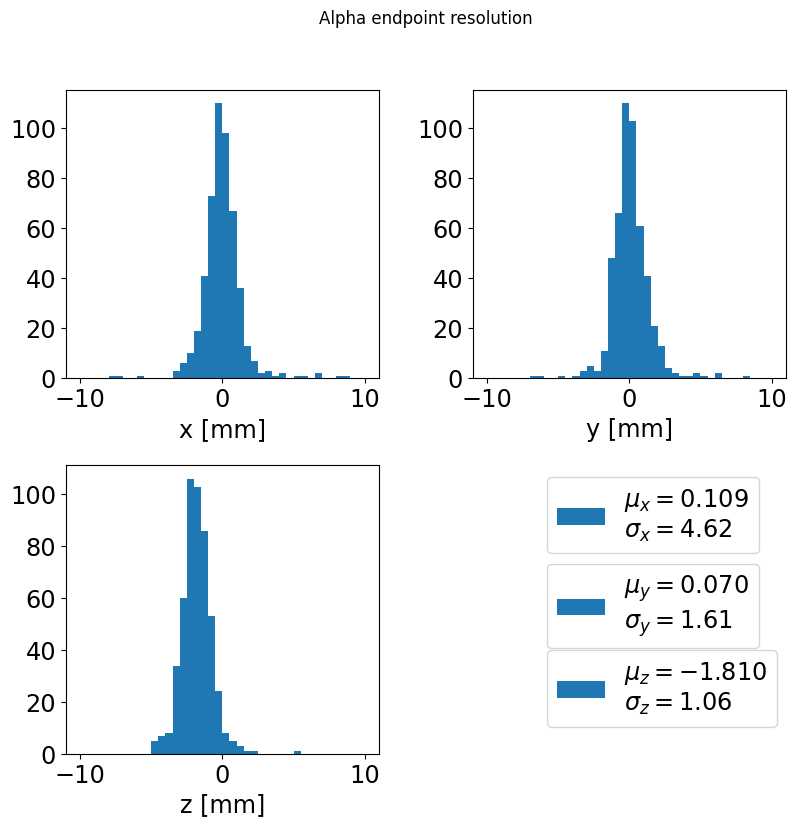

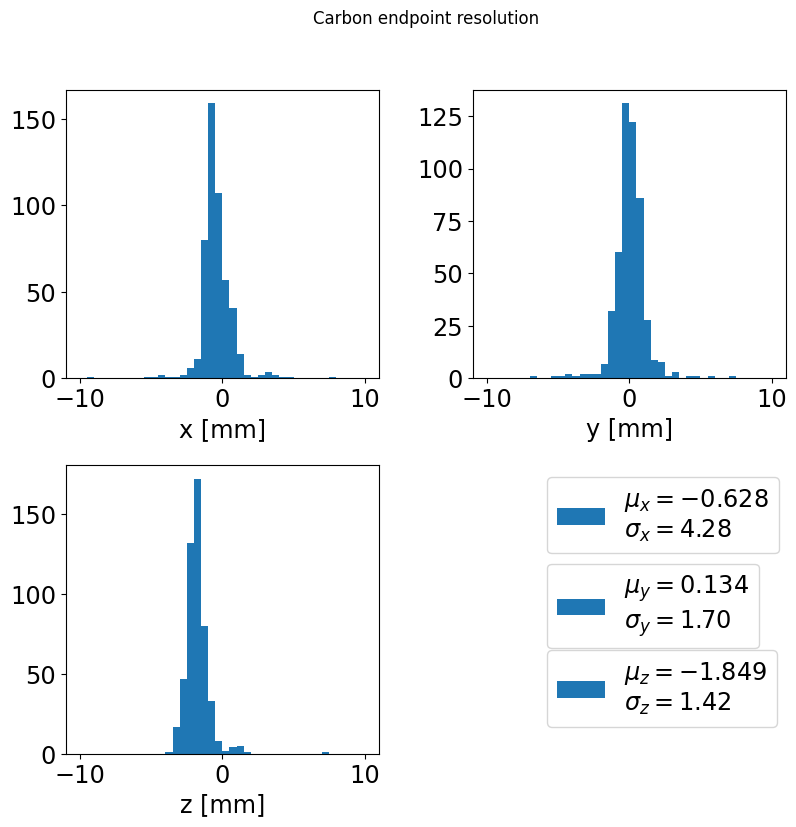

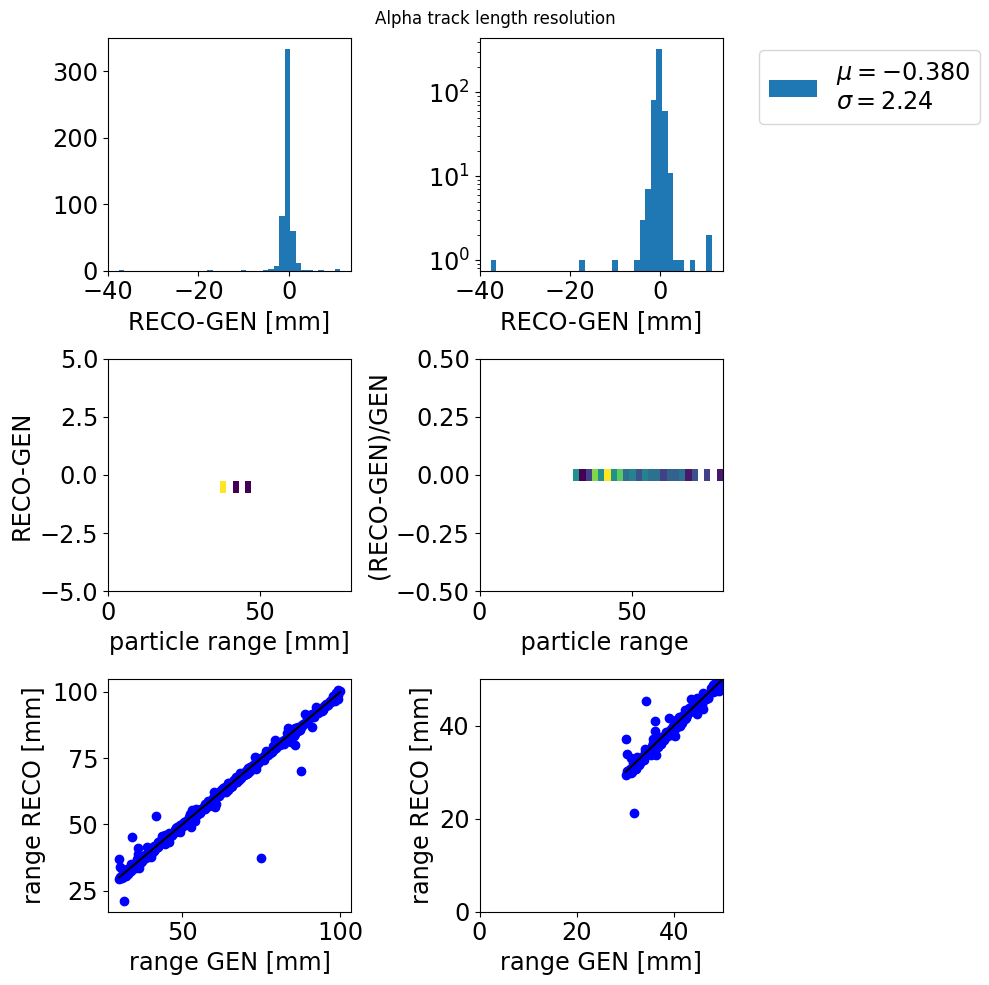

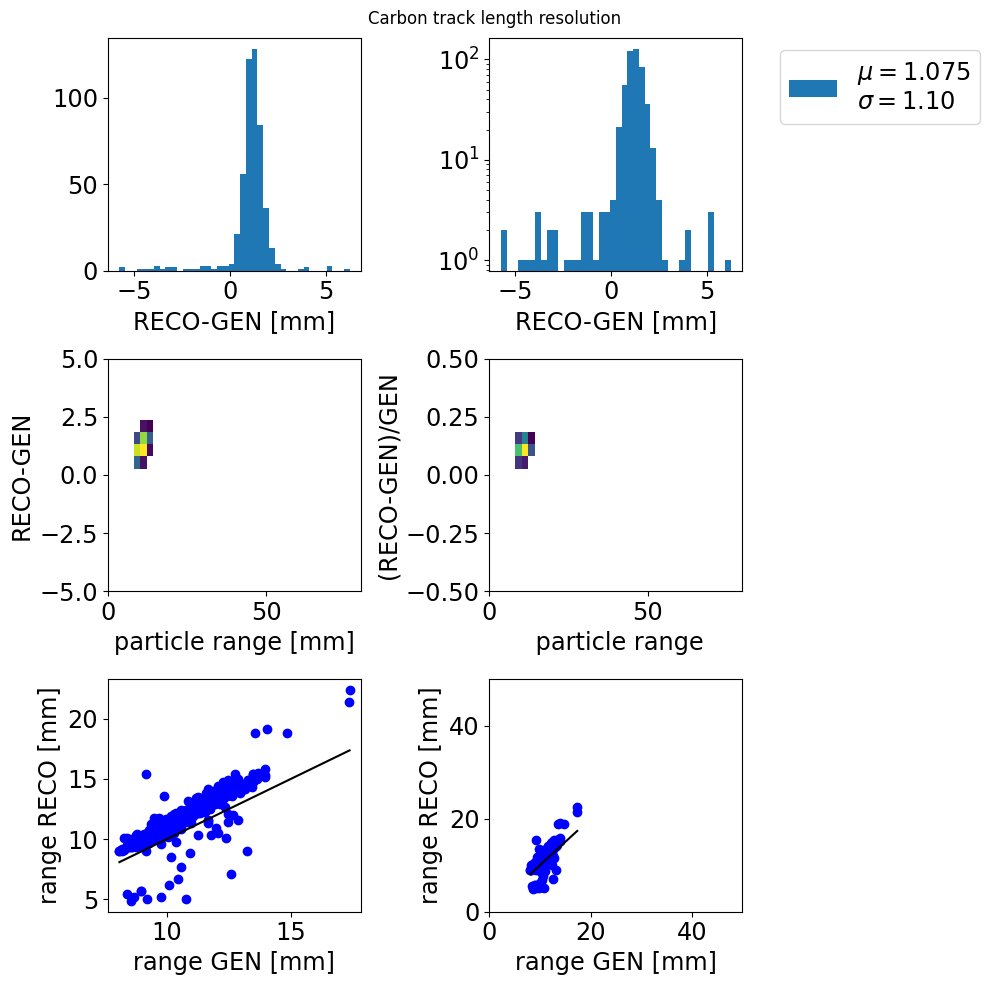

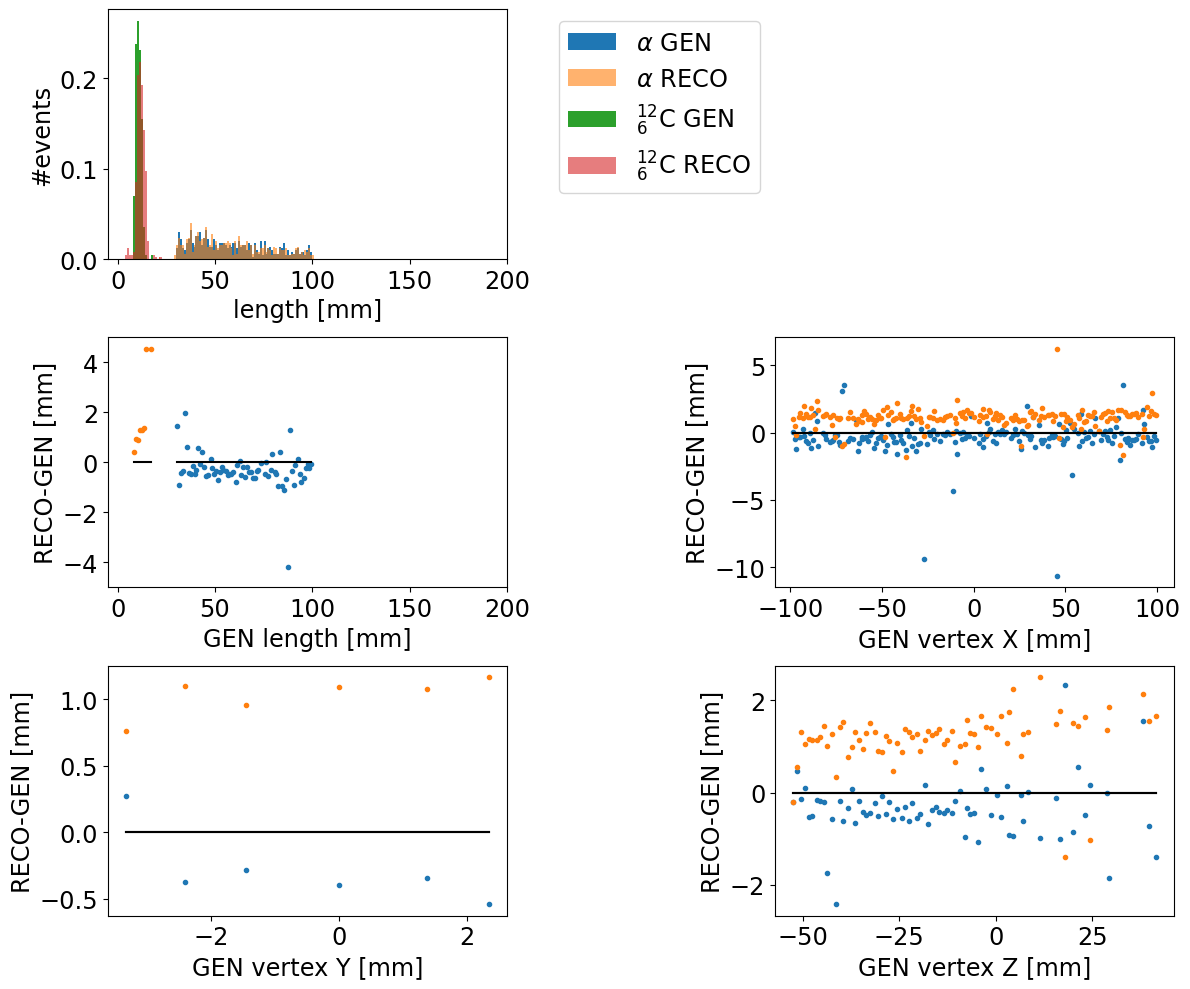

In [11]:
import plotting_functions as plf
importlib.reload(plf)

partName = "Carbon"
d_reco = np.sqrt((df["x"+partName+"_reco"] - df["xVtx_reco"])**2 + 
                     (df["y"+partName+"_reco"] - df["yVtx_reco"])**2 + 
                     (df["z"+partName+"_reco"] - df["zVtx_reco"])**2 )


partName = "Alpha"
d_sim = np.sqrt((df["x"+partName+"_sim"] - df["xVtx_sim"])**2 + 
                     (df["y"+partName+"_sim"] - df["yVtx_sim"])**2 + 
                     (df["z"+partName+"_sim"] - df["zVtx_sim"])**2 )

#mask = (df["pullAlpha"]<-10)*(np.abs(df["xAlpha_sim"])<100)*(np.abs(df["yAlpha_sim"])<90)*(np.abs(df["zAlpha_sim"])<50)
#mask = np.abs(d_reco-15)>0
mask = (d_sim<100)*(d_sim>30)

plf.controlPlots(df[mask])
plf.plotEndPointRes(df=df[mask], edge="Vtx", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df[mask], edge="Alpha", coordinates=["x", "y", "z"])
plf.plotEndPointRes(df=df[mask], edge="Carbon", coordinates=["x", "y", "z"])

plf.plotLengthPull(df[mask], partName="Alpha")
plf.plotLengthPull(df[mask], partName="Carbon")
plf.plotLengthPullEvolution(df[mask])

### Resolution plots in UVWT

In [12]:
import utility_functions as utils
importlib.reload(utils)

batchSize = 32
dataset = tf.data.Dataset.load('MergedEvent_Track3D_TwoProng_gun_MC', compression="GZIP")

data = dataset.map(lambda x: tf.reshape(x["sim"][1], (1,-1)))
data = data.map(lambda x: tf.reshape(x, (-1,3,3)))
data = data.map(lambda x: utils.XYZtoUVWT_event(x))
data = data.map(lambda x: tf.reshape(x, (-1,12))).unbatch().as_numpy_iterator()

df = pd.DataFrame(data, columns=utils.columnsUVWT)

data = dataset.map(lambda x: tf.reshape(x["reco"][1], (1,-1)))
data = data.map(lambda x: tf.reshape(x, (-1,3,3)))
data = data.map(lambda x: utils.XYZtoUVWT_event(x))
data = data.map(lambda x: tf.reshape(x, (-1,12))).unbatch().as_numpy_iterator()
df_reco = pd.DataFrame(data, columns=utils.columnsUVWT)

df = df.merge(df_reco, left_index=True, right_index=True, suffixes=("_sim", "_reco"), how="outer");

2025-12-02 11:07:09.025321: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-12-02 11:07:41.327647: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


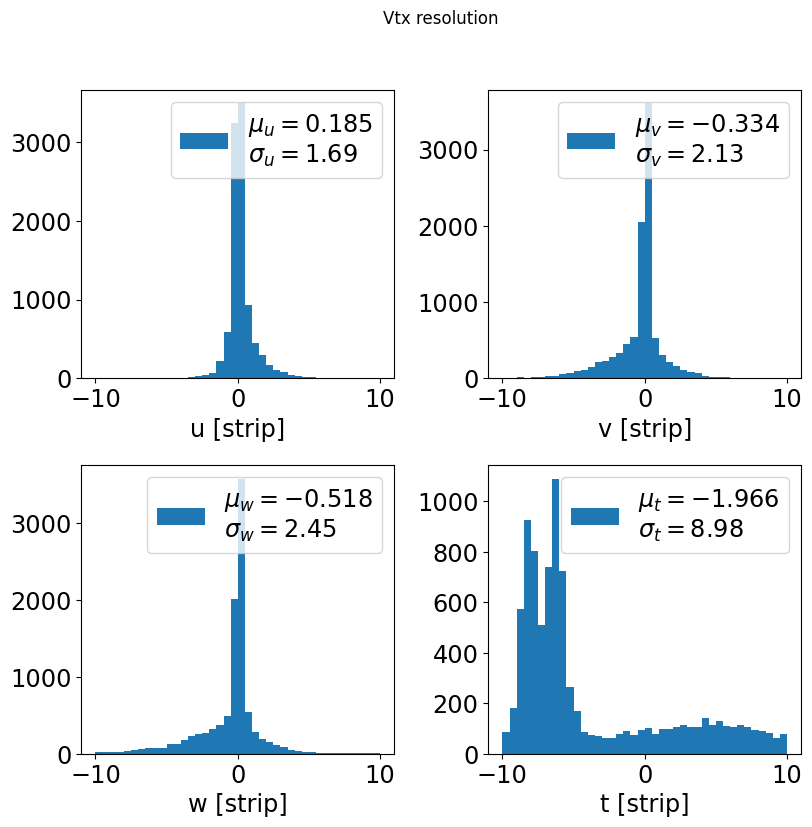

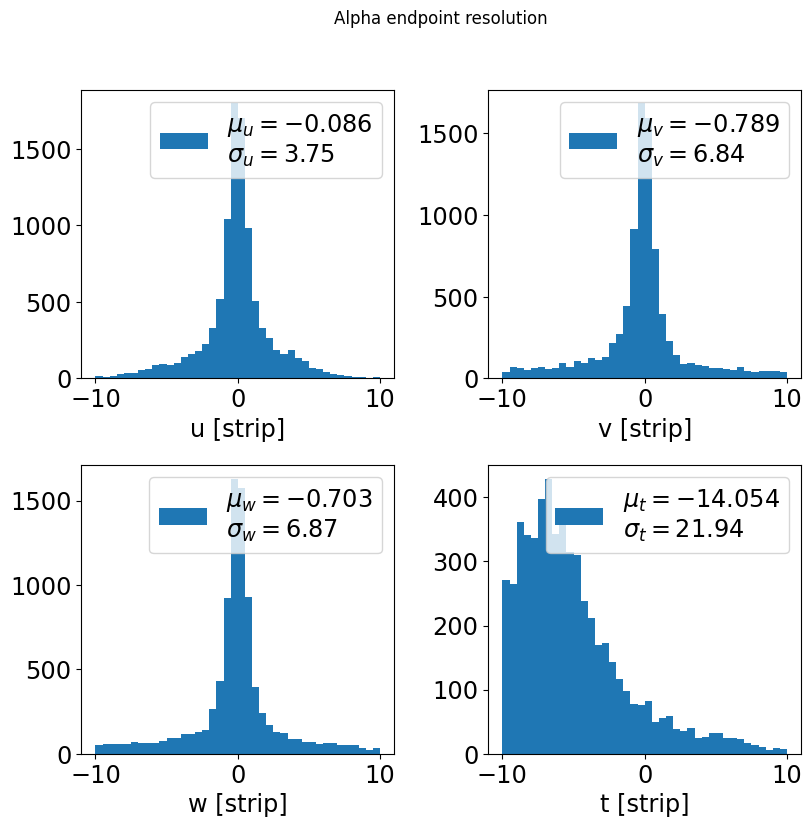

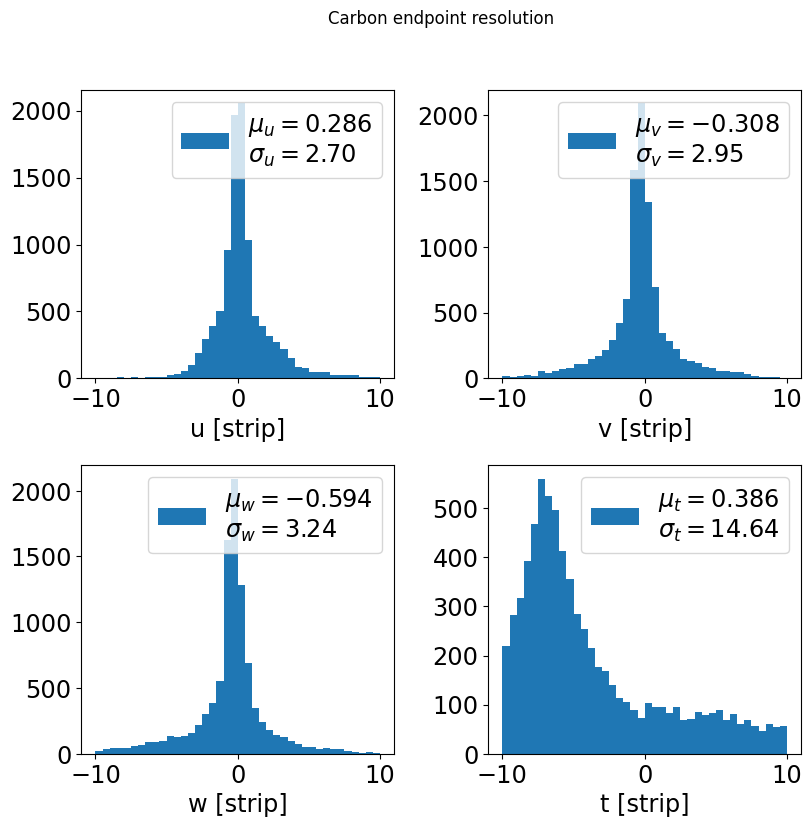

In [13]:
import plotting_functions as plf
importlib.reload(plf)

plf.plotEndPointRes(df=df, edge="Vtx", coordinates=["u", "v", "w", "t"])
plf.plotEndPointRes(df=df, edge="Alpha", coordinates=["u", "v", "w", "t"])
plf.plotEndPointRes(df=df, edge="Carbon", coordinates=["u", "v", "w", "t"])